In [1]:
import os
import sys
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.preprocessing import StandardScaler, normalize 
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

import umap
import hdbscan

import warnings
warnings.filterwarnings("ignore")

In [2]:
INPUT_DIR = "../../data/embedded"
LABELS_PATH = "../../data/preprocessed/cleaned_labels.csv"
OUTPUT_DIR = "../../data/results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# LOAD DATA
def load_data_recursive(input_dir):
    embeddings_list = []
    filenames = []

    print(f"Scanning '{input_dir}' for embeddings...")

    files_found = 0
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".npy"):
                file_path = os.path.join(root, file)

                try:
                    data = np.load(file_path)

                    if data.ndim == 0:
                        continue
                    elif data.ndim == 2:
                        data = data.squeeze()

                    if data.shape != (1024,):
                        continue

                    embeddings_list.append(data)
                    filenames.append(file.replace(".npy", ""))
                    files_found += 1

                except Exception as e:
                    print(f"Error loading {file}: {e}")

    if files_found == 0:
        return None, None

    print(f"Found {files_found} valid files.")

    X = np.vstack(embeddings_list)

    if not os.path.exists(INPUT_DIR):
        print(f"Error: Directory '{INPUT_DIR}' not found.")
        sys.exit(0)
    
    if X is None:
        print("No valid embeddings found. Check your directory.")
        sys.exit(0)
    
    print(f"Final Matrix Shape: {X.shape} (Samples: {X.shape[0]}, Features: {X.shape[1]})")
    return X, filenames

In [4]:
print("1. Loading data...")
X, filenames = load_data_recursive(INPUT_DIR)

1. Loading data...
Scanning '../../data/embedded' for embeddings...
Found 16272 valid files.
Final Matrix Shape: (16272, 1024) (Samples: 16272, Features: 1024)


In [5]:
print("2. Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("3. Normalizing data...") # Cosine distance
X_norm = normalize(X_scaled, norm="l2")

print("4. Reducing with UMAP")
reducer = umap.UMAP(n_neighbors=30, n_components=10, min_dist=0.0, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(X_norm)

2. Scaling features...
3. Normalizing data...
4. Reducing with UMAP


In [6]:
print("5. Clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric="euclidean")

preds = clusterer.fit_predict(X_umap)

n_clusters = len(set(preds)) - (1 if -1 in preds else 0)
n_noise = list(preds).count(-1)
print(f"HDBSCAN found {n_clusters} clusters and {n_noise}/{len(preds)} noise points.")

5. Clustering with HDBSCAN...
HDBSCAN found 6 clusters and 1045/16272 noise points.


In [7]:
print("6. Reducing to 2D for plotting...")
reducer_2d = umap.UMAP(n_neighbors=30, n_components=2, min_dist=0.1, metric="cosine", random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_umap)

6. Reducing to 2D for plotting...


In [8]:
def build_plot_dataframe(data, labels):
    df_plot = pd.DataFrame(data, columns=['UMAP 1', 'UMAP 2'])
    df_plot['Cluster'] = labels.astype(str)
    df_plot['Source'] = filenames
    df_plot['ecg_id'] = df_plot['Source'].astype(int)
    
    try:
        true_labels_df = pd.read_csv(LABELS_PATH)
        df_plot = df_plot.merge(true_labels_df[['ecg_id', 'label']], on='ecg_id', how='left')
        df_plot['label'] = df_plot['label'].fillna('Unknown')
    except Exception as e:
        df_plot['label'] = 'Unknown'

    return df_plot

df_plot = build_plot_dataframe(X_umap_2d, preds)

In [9]:
print("=" * 30)
print("UMAP + HDBSCAN METRICS")
print("=" * 30)

valid_idx = (df_plot["label"] != "Unknown") & (df_plot["Cluster"] != -1)
true_labels_valid = df_plot.loc[valid_idx, "label"]
pred_clusters_valid = df_plot.loc[valid_idx, "Cluster"]

if len(true_labels_valid) > 1:
    ari = adjusted_rand_score(true_labels_valid, pred_clusters_valid)
    nmi = normalized_mutual_info_score(true_labels_valid, pred_clusters_valid)
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Info (NMI):  {nmi:.4f}")
    print(f"Evaluated on {len(true_labels_valid)} core points")
else:
    print("Could not calculate ARI/NMI. Not enough valid true labels.")

UMAP + HDBSCAN METRICS
Adjusted Rand Index (ARI): 0.0906
Normalized Mutual Info (NMI):  0.0980
Evaluated on 16272 core points


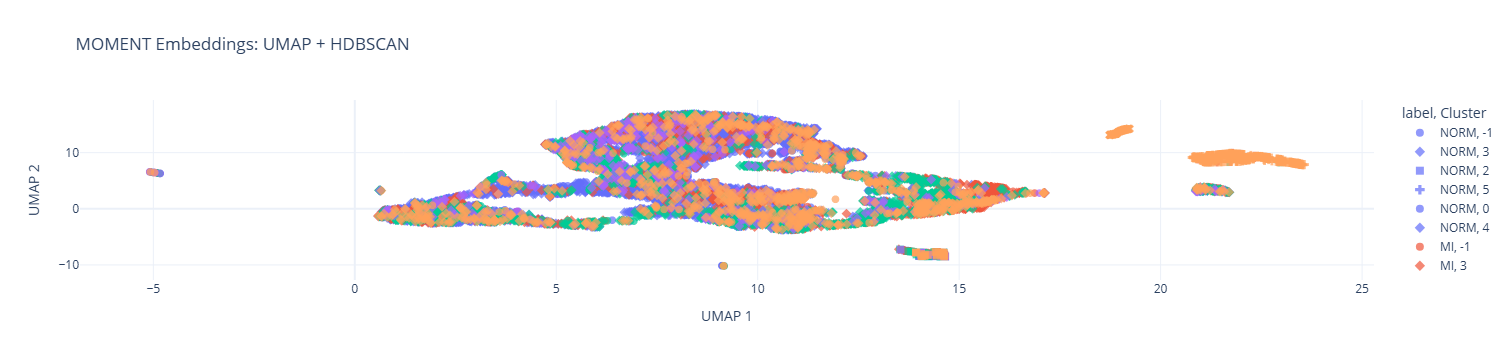

In [10]:
fig = px.scatter(
    df_plot,
    x = "UMAP 1",
    y = "UMAP 2",
    color = "label",
    symbol = "Cluster",
    hover_name = "Source",
    hover_data = {"label": True, "Cluster": True, "UMAP 1": False, "UMAP 2": False},
    title = "MOMENT Embeddings: UMAP + HDBSCAN",
    color_discrete_sequence = px.colors.qualitative.Plotly
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(template="plotly_white")
fig.show()